# Plot Trajectories From a Fitted Keypoint MoSeq Model

This notebook loads a fitted Keypoint MoSeq model, extracts or reloads the model results, and saves trajectory plots for every syllable with a usable typical trajectory.


In [6]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import keypoint_moseq as kpms

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "Keypoint_moseq_analysis":
    REPO_ROOT = PROJECT_ROOT.parent
else:
    REPO_ROOT = PROJECT_ROOT

POSE_TRACKING_DIR = REPO_ROOT / "Pose_Tracking"
if str(POSE_TRACKING_DIR) not in sys.path:
    sys.path.insert(0, str(POSE_TRACKING_DIR))

from keypoint_moseq_utils import load_kpms_inputs


## Paths and Settings

Set these to your fitted project and model name.


In [7]:
project_dir = REPO_ROOT / "Pose_Tracking" / "keypoint_moseq_project_home_cage"
model_name = "2026_05_13-23_29_52"
#
# 2026_05_13-17_21_57
# 2026_05_13-12_27_28


# Explicitly use the legacy full-recording inputs file for older models.
# inputs_path = project_dir / "home_cage_kpms_inputs.pkl"

# Use the valid-frame filtered inputs file.
inputs_path = project_dir / "home_cage_kpms_inputs_valid_frames.pkl"

output_dir = project_dir / model_name / "trajectory_plots_all"

save_gifs = True
save_mp4s = False
density_sample = False

# Trajectory window settings.
pre = 0.167
post = 0.5
min_frequency = 0.0
min_duration = 3

# Plot styling.
keypoint_colormap = "autumn"
use_bodyparts = None  # Example: ["Nose", "Head", "Tail_Base"]
plot_options = {}
get_limits_pctl = 0
padding = {"left": 0.1, "right": 0.1, "top": 0.2, "bottom": 0.2}
sampling_options = {"n_neighbors": 50}

project_dir, output_dir


(Path('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/keypoint_moseq_project_home_cage'),
 Path('c:/Users/alber/OneDrive/Documents/GitHub/Fiber_Photometry_revisions/Pose_Tracking/keypoint_moseq_project_home_cage/2026_05_13-23_29_52/trajectory_plots_all'))

In [8]:
def resolve_inputs_path(project_dir, inputs_path=None):
    if inputs_path is not None:
        return Path(inputs_path)

    candidates = sorted(Path(project_dir).glob("*.pkl"))
    if not candidates:
        raise FileNotFoundError(f"No .pkl inputs file found in {project_dir}")
    return candidates[0]


def load_results_or_extract(project_dir, model_name):
    project_dir = Path(project_dir)
    model_dir = project_dir / model_name
    results_dir = model_dir / "results"

    if results_dir.exists():
        print(f"Loading saved results from: {results_dir}")
        return kpms.load_results(str(project_dir), model_name)

    print("Saved results not found; extracting from checkpoint...")
    kpms.reindex_syllables_in_checkpoint(str(project_dir), model_name)
    model, data, metadata, _ = kpms.load_checkpoint(str(project_dir), model_name)
    results = kpms.extract_results(model, metadata, str(project_dir), model_name)
    kpms.save_results_as_csv(results, str(project_dir), model_name)
    return results


def validate_results_match_inputs(coordinates, results):
    coord_keys = set(coordinates)
    result_keys = set(results)
    missing_in_coords = sorted(result_keys - coord_keys)
    missing_in_results = sorted(coord_keys - result_keys)
    mismatches = []
    for key in sorted(coord_keys & result_keys):
        n_coord = coordinates[key].shape[0]
        n_res = len(results[key].get("syllable", results[key].get("syllables", [])))
        if n_coord != n_res:
            mismatches.append((key, n_coord, n_res))
    if missing_in_coords or missing_in_results or mismatches:
        preview = mismatches[:5]
        raise ValueError(
            "Loaded inputs and model results do not match. "
            f"missing_in_coords={len(missing_in_coords)}, "
            f"missing_in_results={len(missing_in_results)}, "
            f"frame_count_mismatches={len(mismatches)}. "
            f"Examples: {preview}"
        )


def generate_all_trajectory_plots(
    coordinates,
    results,
    output_dir,
    *,
    fps,
    bodyparts=None,
    skeleton=None,
    use_bodyparts=None,
    pre=0.167,
    post=0.5,
    min_frequency=0.0,
    min_duration=3,
    keypoint_colormap="autumn",
    plot_options=None,
    get_limits_pctl=0,
    padding=None,
    lims=None,
    save_gifs=True,
    save_mp4s=False,
    density_sample=False,
    sampling_options=None,
):
    if fps is None:
        raise ValueError("fps must be provided")

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    bodyparts = list(bodyparts or [])
    skeleton = list(skeleton or [])
    padding = padding or {"left": 0.1, "right": 0.1, "top": 0.2, "bottom": 0.2}
    sampling_options = dict(sampling_options or {"n_neighbors": 50})
    plot_options = dict(plot_options or {})
    plot_options.update({"keypoint_colormap": keypoint_colormap})

    if use_bodyparts is None:
        use_bodyparts = bodyparts

    pre_frames = round(pre * fps)
    post_frames = round(post * fps)
    edges = [] if len(skeleton) == 0 else kpms.get_edges(use_bodyparts, skeleton)

    typical_trajectories = kpms.get_typical_trajectories(
        coordinates,
        results,
        pre_frames,
        post_frames,
        min_frequency,
        min_duration,
        bodyparts,
        use_bodyparts,
        density_sample,
        sampling_options,
    )

    syllable_ixs = sorted(int(s) for s in typical_trajectories.keys())
    if not syllable_ixs:
        raise ValueError("No syllables had usable trajectories.")

    titles = [f"Syllable{s}" for s in syllable_ixs]
    Xs = np.stack([typical_trajectories[s] for s in syllable_ixs])

    if Xs.shape[-1] != 2:
        raise ValueError("This notebook currently expects 2D trajectories.")

    Xs_2D = Xs * np.array([1, -1])
    if lims is None:
        lims = kpms.get_limits(Xs_2D, pctl=get_limits_pctl, **padding)

    for title, X in zip(titles, Xs_2D):
        fig, ax, rasters = kpms.plot_trajectories(
            [title],
            X[None],
            lims,
            edges=edges,
            return_rasters=(save_gifs or save_mp4s),
            **plot_options,
        )
        fig.savefig(output_dir / f"{title}.pdf")
        plt.close(fig)

        if save_gifs:
            frame_duration = (pre_frames + post_frames) / len(rasters) / fps
            kpms.save_gif(rasters, output_dir / f"{title}.gif", duration=frame_duration)
        if save_mp4s:
            use_fps = len(rasters) / (pre_frames + post_frames) * fps
            kpms.write_video_clip(rasters, output_dir / f"{title}.mp4", fps=use_fps)

    fig, ax, rasters = kpms.plot_trajectories(
        titles,
        Xs_2D,
        lims,
        edges=edges,
        return_rasters=(save_gifs or save_mp4s),
        **plot_options,
    )
    fig.savefig(output_dir / "all_trajectories.pdf")
    plt.show()

    if save_gifs:
        frame_duration = (pre_frames + post_frames) / len(rasters) / fps
        kpms.save_gif(rasters, output_dir / "all_trajectories.gif", duration=frame_duration)
    if save_mp4s:
        use_fps = len(rasters) / (pre_frames + post_frames) * fps
        kpms.write_video_clip(rasters, output_dir / "all_trajectories.mp4", fps=use_fps)

    pd.DataFrame({"syllable": syllable_ixs}).to_csv(output_dir / "generated_syllables.csv", index=False)
    print(f"Saved {len(syllable_ixs)} syllable plots to {output_dir}")
    return syllable_ixs


## Load Inputs and Results


In [9]:
resolved_inputs_path = resolve_inputs_path(project_dir, inputs_path)
payload = load_kpms_inputs(resolved_inputs_path)

coordinates = payload["coordinates"]
confidences = payload["confidences"]
bodyparts = payload["bodyparts"]
skeleton = payload["skeleton"]
metadata_df = payload["metadata_df"]

results = load_results_or_extract(project_dir, model_name)
validate_results_match_inputs(coordinates, results)

print(f"Inputs file: {resolved_inputs_path}")
print(f"Recordings loaded: {len(coordinates)}")
print(f"Results loaded for: {len(results)} recordings")
metadata_df.head()


Loading saved results from: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\results
Inputs file: c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\home_cage_kpms_inputs_valid_frames.pkl
Recordings loaded: 50
Results loaded for: 50 recordings


,recording_name,subject_name,trial_name,track_name,source_h5,n_frames,fps,bout_name,bout_start_s,bout_end_s
0,n5_agent,n5,n5-240823-085032,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
1,n5_subject,n5,n5-240823-085032,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15058,10.0,None,None,None
2,n6_agent,n6,n6-240823-101436,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15071,10.0,None,None,None
3,n6_subject,n6,n6-240823-101436,subject,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15071,10.0,None,None,None
4,n7_agent,n7,n7-240824-062103,agent,C:\Users\alber\OneDrive\Desktop\PC_Lab\Photome...,15093,10.0,None,None,None


## Generate and Save Trajectory Plots


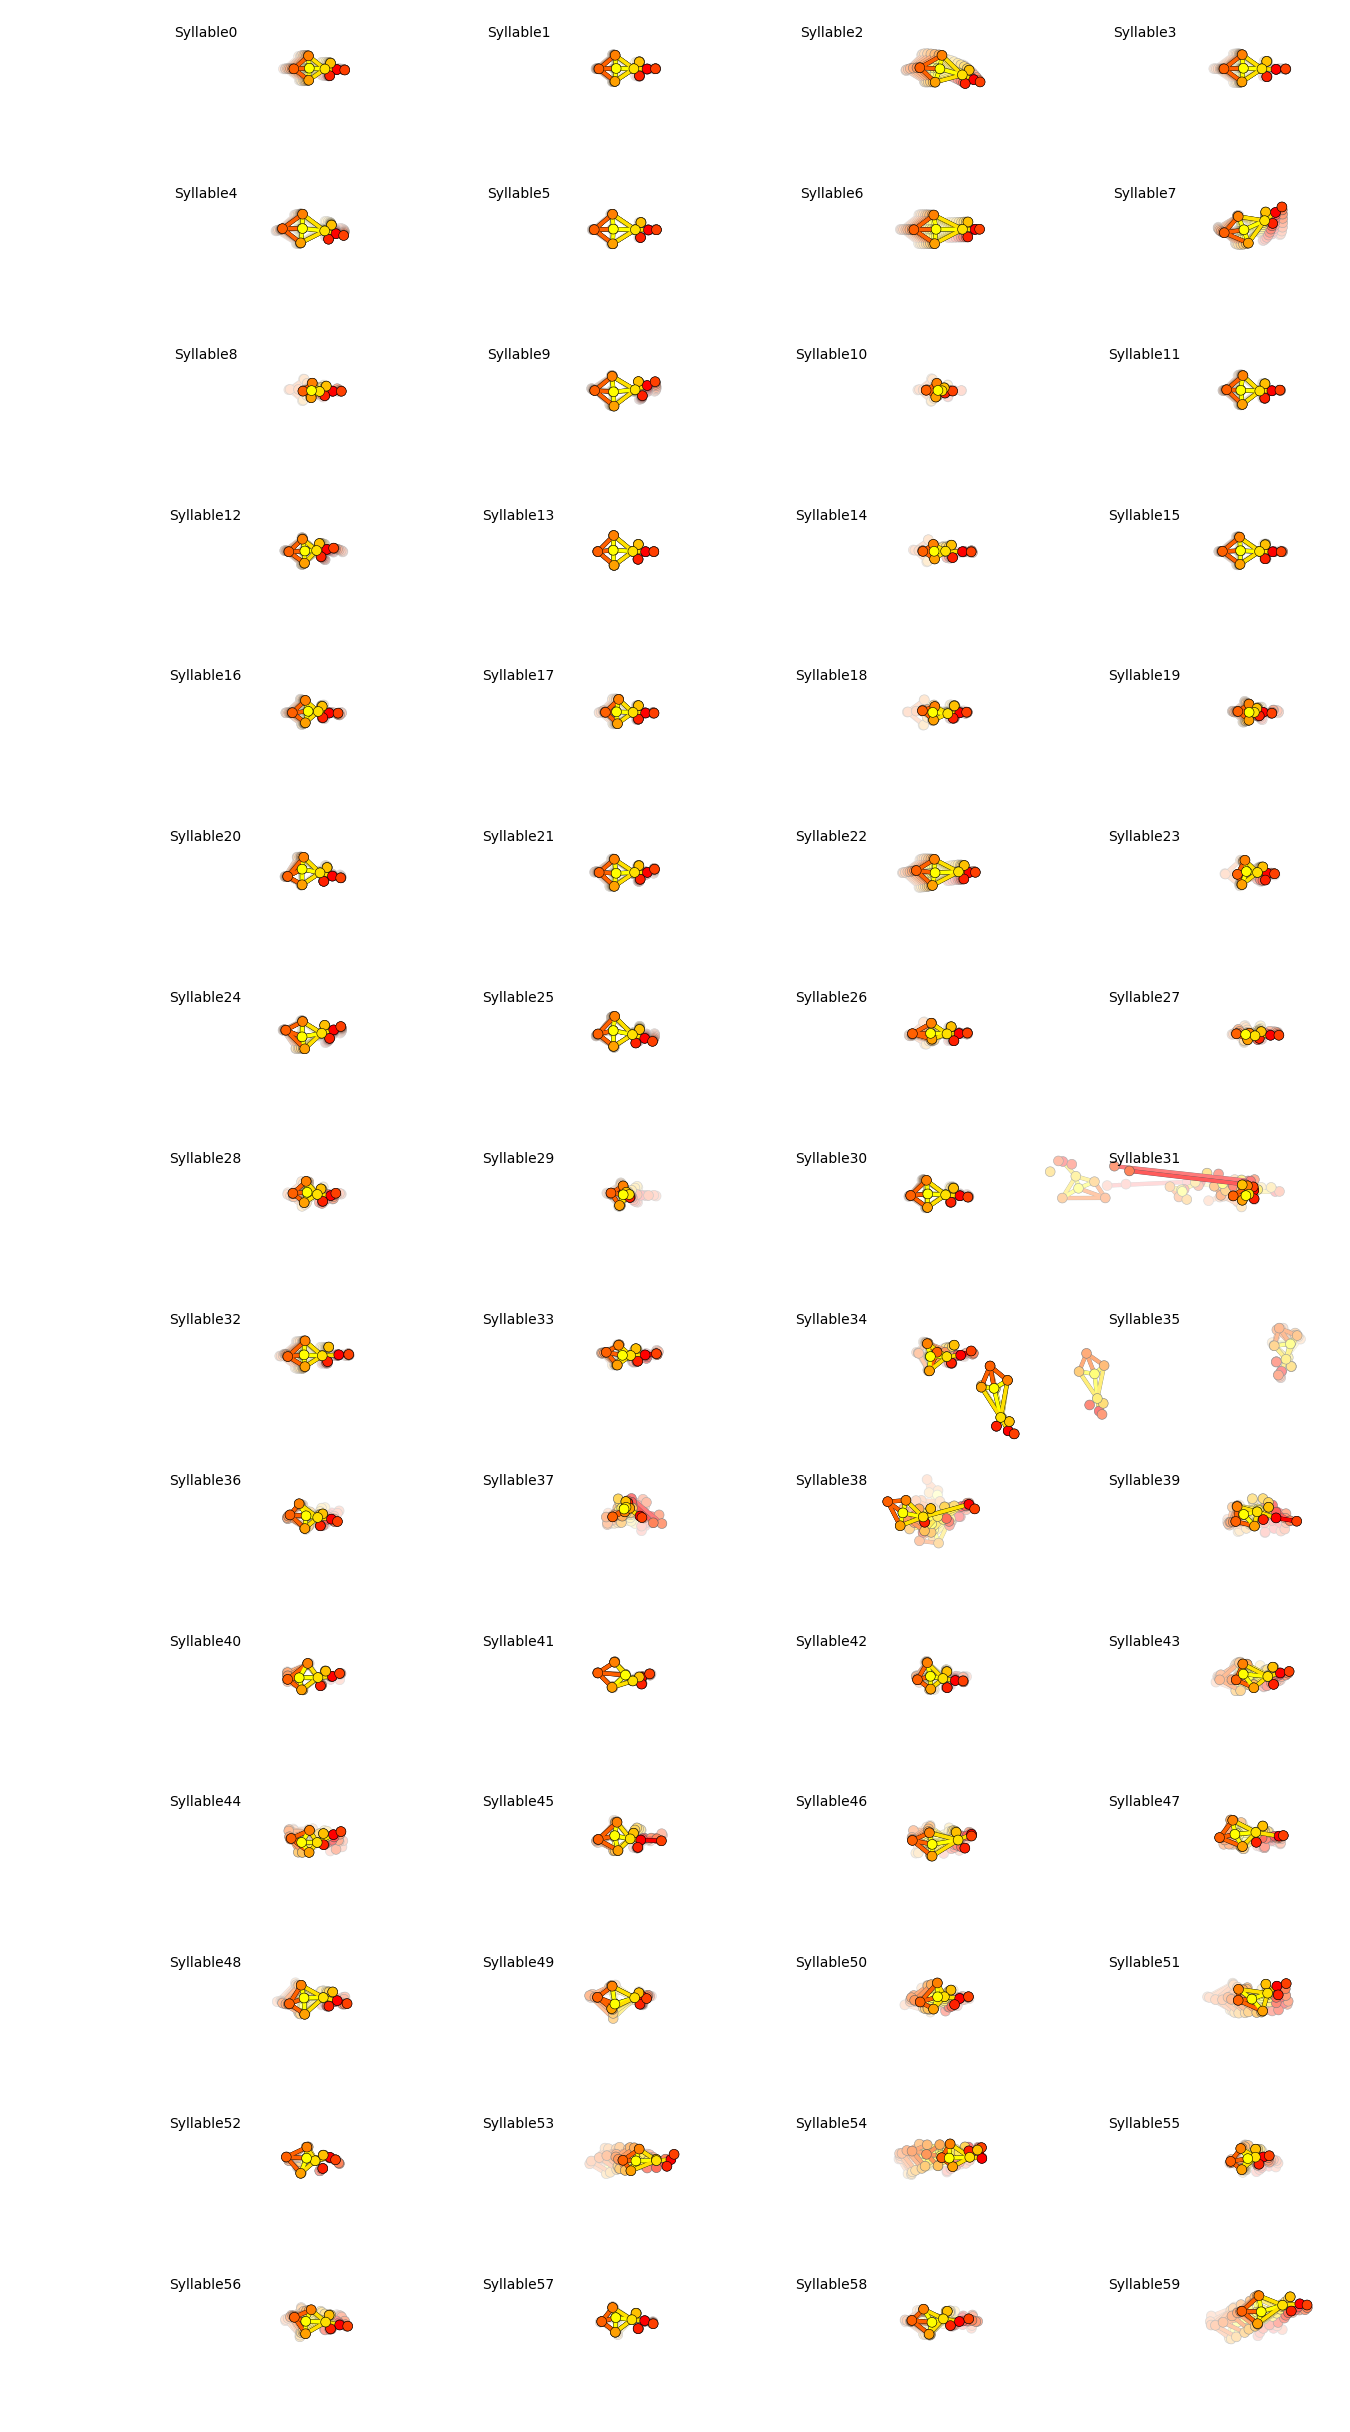

Saved 60 syllable plots to c:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_05_13-23_29_52\trajectory_plots_all


(60, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [10]:
generated_syllables = generate_all_trajectory_plots(
    coordinates,
    results,
    output_dir=output_dir,
    fps=float(metadata_df["fps"].iloc[0]),
    bodyparts=bodyparts,
    skeleton=skeleton,
    use_bodyparts=use_bodyparts,
    pre=pre,
    post=post,
    min_frequency=min_frequency,
    min_duration=min_duration,
    keypoint_colormap=keypoint_colormap,
    plot_options=plot_options,
    get_limits_pctl=get_limits_pctl,
    padding=padding,
    save_gifs=save_gifs,
    save_mp4s=save_mp4s,
    density_sample=density_sample,
    sampling_options=sampling_options,
)

len(generated_syllables), generated_syllables[:10]


In [12]:
import pandas as pd
from keypoint_moseq_utils import diagnose_syllable_inventory

syllable_frames_path = project_dir / model_name / "syllable_frames.csv"
# syllable_frames_path = r"C:\Users\alber\OneDrive\Documents\GitHub\Fiber_Photometry_revisions\Pose_Tracking\keypoint_moseq_project_home_cage\2026_05_13-07_32_28\syllable_frames.csv"
syllable_frames = pd.read_csv(syllable_frames_path)

summary, redundant_pairs = diagnose_syllable_inventory(
    syllable_frames,
    min_occupancy_frac=0.005,   # flag syllables with <0.5% of frames
    short_run_frames=3,         # flag very fragmented states
    min_pair_frames=100,        # only compare reasonably supported syllables
    top_n_pairs=20,
)

summary

,syllable,n_frames,n_recordings,occupancy_frac,recording_frac,n_runs,mean_run_length_frames,median_run_length_frames,mean_run_length_s,median_run_length_s,...,n_distinct_next,outgoing_entropy,n_incoming_transitions,n_distinct_prev,incoming_entropy,frames_per_run,is_low_occupancy,is_fragmented,is_low_support,artifact_flag_count
0,54,35,7,0.000046,0.14,8,4.375000,3.0,0.437500,0.30,...,5,2.250000,8,5,2.000000,4.375000,True,True,True,3
1,46,26,10,0.000034,0.20,11,2.363636,2.0,0.236364,0.20,...,6,2.413088,11,5,2.040373,2.363636,True,True,False,2
2,45,30,8,0.000040,0.16,11,2.727273,2.0,0.272727,0.20,...,7,2.663533,11,5,2.231270,2.727273,True,True,False,2
3,51,30,10,0.000040,0.20,10,3.000000,3.0,0.300000,0.30,...,7,2.721928,10,4,1.846439,3.000000,True,True,False,2
4,39,32,11,0.000042,0.22,16,2.000000,1.5,0.200000,0.15,...,7,2.530639,16,8,2.827820,2.000000,True,True,False,2
5,53,32,8,0.000042,0.16,8,4.000000,4.0,0.400000,0.40,...,4,1.905639,8,5,2.250000,4.000000,True,False,True,2
6,48,33,10,0.000044,0.20,11,3.000000,3.0,0.300000,0.30,...,4,1.491115,11,4,1.823068,3.000000,True,True,False,2
7,55,34,8,0.000045,0.16,8,4.250000,4.5,0.425000,0.45,...,5,2.250000,8,5,2.155639,4.250000,True,False,True,2
8,56,35,6,0.000046,0.12,6,5.833333,4.5,0.583333,0.45,...,5,2.251629,6,5,2.251629,5.833333,True,False,True,2
9,58,35,3,0.000046,0.06,4,8.750000,8.0,0.875000,0.80,...,4,2.000000,4,3,1.500000,8.750000,True,False,True,2


## Saved Files


In [14]:
saved_files = sorted(output_dir.glob("*"))
pd.DataFrame({"file": [p.name for p in saved_files]}).head(20)


,file
0,all_trajectories.gif
1,all_trajectories.pdf
2,generated_syllables.csv
3,Syllable0.gif
4,Syllable0.pdf
5,Syllable1.gif
6,Syllable1.pdf
7,Syllable10.gif
8,Syllable10.pdf
9,Syllable11.gif
